<a href="https://colab.research.google.com/github/DeeveshBeegun/machine_learning_handson/blob/main/neural_network/spam_neural_network_hands_on.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-On: Building a Neural Network for Spam Detection

## Goal
In this hands-on, you will build and train a neural network that classifies an email as **Spam** or **Not Spam**.

You will:
1. Convert emails into numerical features
2. Identify the input size
3. Choose hidden layers and neurons
4. Choose activation functions
5. Build the neural network using Keras
6. Inspect the architecture
7. Perform a forward pass
8. Measure prediction error with binary cross-entropy
9. Calculate gradients with backpropagation
10. Train the network with gradient descent


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display, Markdown
import ipywidgets as widgets

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 1. Look at some example emails

Before building a neural network, inspect a few emails and think about what information could help distinguish spam from legitimate messages.


In [ ]:
emails = [
    "Congratulations! You have WON a FREE prize!!! Click http://claim-now.com",
    "Hi Sarah, can we move tomorrow's project meeting to 2 PM?",
    "URGENT!!! Your account has been selected for a CASH reward. Click now!",
    "Please find attached the report from yesterday's meeting.",
    "WIN MONEY NOW!!! FREE FREE FREE!!! Visit http://winner.com"
]

for i, email in enumerate(emails, start=1):
    print(f"\nEmail {i}")
    print("-" * 60)
    print(email)



Email 1
------------------------------------------------------------
Congratulations! You have WON a FREE prize!!! Click http://claim-now.com

Email 2
------------------------------------------------------------
Hi Sarah, can we move tomorrow's project meeting to 2 PM?

Email 3
------------------------------------------------------------
URGENT!!! Your account has been selected for a CASH reward. Click now!

Email 4
------------------------------------------------------------
Please find attached the report from yesterday's meeting.

Email 5
------------------------------------------------------------
WIN MONEY NOW!!! FREE FREE FREE!!! Visit http://winner.com


### Discussion

Can a neural network directly use these sentences as numerical inputs?

For this introductory exercise, we will manually convert each email into a small set of numerical features.


In [ ]:
spam_words = [
    "free",
    "win",
    "won",
    "money",
    "cash",
    "prize",
    "urgent",
    "reward"
]

def extract_features(email):
    words = email.lower().split()

    spam_word_count = sum(
        word.strip("!.,?") in spam_words
        for word in words
    )

    exclamation_count = email.count("!")
    link_count = email.lower().count("http")
    email_length = len(email)

    uppercase_words = sum(
        word.isupper() and len(word) > 1
        for word in email.split()
    )

    return [
        spam_word_count,
        exclamation_count,
        link_count,
        email_length,
        uppercase_words
    ]


## 2. Convert the emails into neural-network inputs

We will represent every email using the numerical features below:

- Number of suspicious/spam words
- Number of exclamation marks
- Number of links
- Email length
- Number of uppercase words


In [ ]:
features = np.array([
    extract_features(email)
    for email in emails
])

feature_names = [
    "Spam words",
    "Exclamation marks",
    "Links",
    "Email length",
    "Uppercase words"
]

df = pd.DataFrame(
    features,
    columns=feature_names
)

df["Email"] = emails

display(df)


,Spam words,Exclamation marks,Links,Email length,Uppercase words,Email
0,3,4,1,72,2,Congratulations! You have WON a FREE prize!!! ...
1,0,0,0,57,1,"Hi Sarah, can we move tomorrow's project meeti..."
2,3,4,0,70,2,URGENT!!! Your account has been selected for a...
3,0,0,0,57,0,Please find attached the report from yesterday...
4,5,6,1,58,6,WIN MONEY NOW!!! FREE FREE FREE!!! Visit http:...


## Interactive Exercise 1 — Identify the input size

How many numerical values enter the neural network for each email?


In [ ]:
#@title Exercise 1 checker
import hashlib as _hashlib

_check_salt = 'spam-nn-student-check-v1'
def _digest_answer(value):
    return _hashlib.sha256((_check_salt + "|" + str(value)).encode()).hexdigest()

input_answer = widgets.IntSlider(
    value=1,
    min=1,
    max=10,
    step=1,
    description="Inputs:"
)

check_button = widgets.Button(description="Check answer")
output = widgets.Output()
_expected_digest = '04b5e3b6753b8e49bd566242709b41d2ef10d3f5d585e3aba23cbac4b661ae80'

def check_input_size(b):
    with output:
        output.clear_output()
        if _digest_answer(input_answer.value) == _expected_digest:
            print("✅ Correct!")
            print(f"The network receives {input_answer.value} numerical input values per email.")
        else:
            print("❌ Try again.")
            print("Count the numerical features used to describe each email.")

check_button.on_click(check_input_size)
display(input_answer, check_button, output)


IntSlider(value=1, description='Inputs:', max=10, min=1)

Button(description='Check answer', style=ButtonStyle())

Output()

## 3. Design the hidden layers

A possible architecture could look like this:

`input features → 8 neurons → 4 neurons → 1 output`

But there is no need to use exactly these hidden-layer sizes.

Use the sliders below to choose your own hidden-layer sizes.


In [ ]:
hidden1_widget = widgets.IntSlider(
    value=8,
    min=1,
    max=32,
    step=1,
    description="Hidden 1:"
)

hidden2_widget = widgets.IntSlider(
    value=4,
    min=1,
    max=32,
    step=1,
    description="Hidden 2:"
)

display(
    hidden1_widget,
    hidden2_widget
)


IntSlider(value=8, description='Hidden 1:', max=32, min=1)

IntSlider(value=4, description='Hidden 2:', max=32, min=1)

## 4. Choose activation functions

For this binary-classification network, choose suitable activation functions for:

- the hidden layers
- the output layer

Think about two questions:

1. Which activation is commonly useful inside hidden Dense layers?
2. Which activation produces a single value that can be interpreted on a 0-to-1 scale?

Use the dropdowns below and check your choices.


In [ ]:
#@title Activation checker
import hashlib as _hashlib

_check_salt = 'spam-nn-student-check-v1'
def _digest_answer(value):
    return _hashlib.sha256((_check_salt + "|" + str(value)).encode()).hexdigest()

hidden_activation = widgets.Dropdown(
    options=["Choose...", "relu", "sigmoid", "softmax"],
    description="Hidden:"
)

output_activation = widgets.Dropdown(
    options=["Choose...", "relu", "sigmoid", "softmax"],
    description="Output:"
)

activation_button = widgets.Button(description="Check choices")
activation_feedback = widgets.Output()
_expected_digest = '3093453ff7d6fc36d0332ad13c65a4539f8d27bdffd4999b88f5919089ceac6d'

def check_activations(b):
    with activation_feedback:
        activation_feedback.clear_output()
        selected = f"{hidden_activation.value}|{output_activation.value}"
        if _digest_answer(selected) == _expected_digest:
            print("✅ Great!")
            print()
            print(f"Hidden layers → {hidden_activation.value}")
            print(f"Output layer → {output_activation.value}")
            print()
            print("The output choice gives one value on a 0-to-1 scale.")
        else:
            print("❌ Try again.")
            print()
            print("Hint:")
            print("• Think about a common nonlinear activation for hidden Dense layers.")
            print("• The output activation should map to a 0-to-1 scale.")

activation_button.on_click(check_activations)
display(hidden_activation, output_activation, activation_button, activation_feedback)


Dropdown(description='Hidden:', options=('Choose...', 'relu', 'sigmoid', 'softmax'), value='Choose...')

Dropdown(description='Output:', options=('Choose...', 'relu', 'sigmoid', 'softmax'), value='Choose...')

Button(description='Check choices', style=ButtonStyle())

Output()

## 5. Build the neural network

Now create the network using TensorFlow/Keras.

Notice that we are only **building the architecture**. We are not compiling or training the model yet.


In [ ]:
def build_network(hidden1=8, hidden2=4):

    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(len(feature_names),)),

        tf.keras.layers.Dense(
            hidden1,
            activation="relu",
            name="hidden_layer_1"
        ),

        tf.keras.layers.Dense(
            hidden2,
            activation="relu",
            name="hidden_layer_2"
        ),

        tf.keras.layers.Dense(
            1,
            activation="sigmoid",
            name="spam_probability"
        )

    ])

    return model


In [ ]:
model = build_network(
    hidden1=hidden1_widget.value,
    hidden2=hidden2_widget.value
)

model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 19)             │           114 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 12)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spam_probability (Dense)        │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 367 (1.43 KB)

 Trainable params: 367 (1.43 KB)

 Non-trainable params: 0 (0.00 B)

### Think about the output layer

Why is there only **one output neuron**?


## 6. Visualize the network


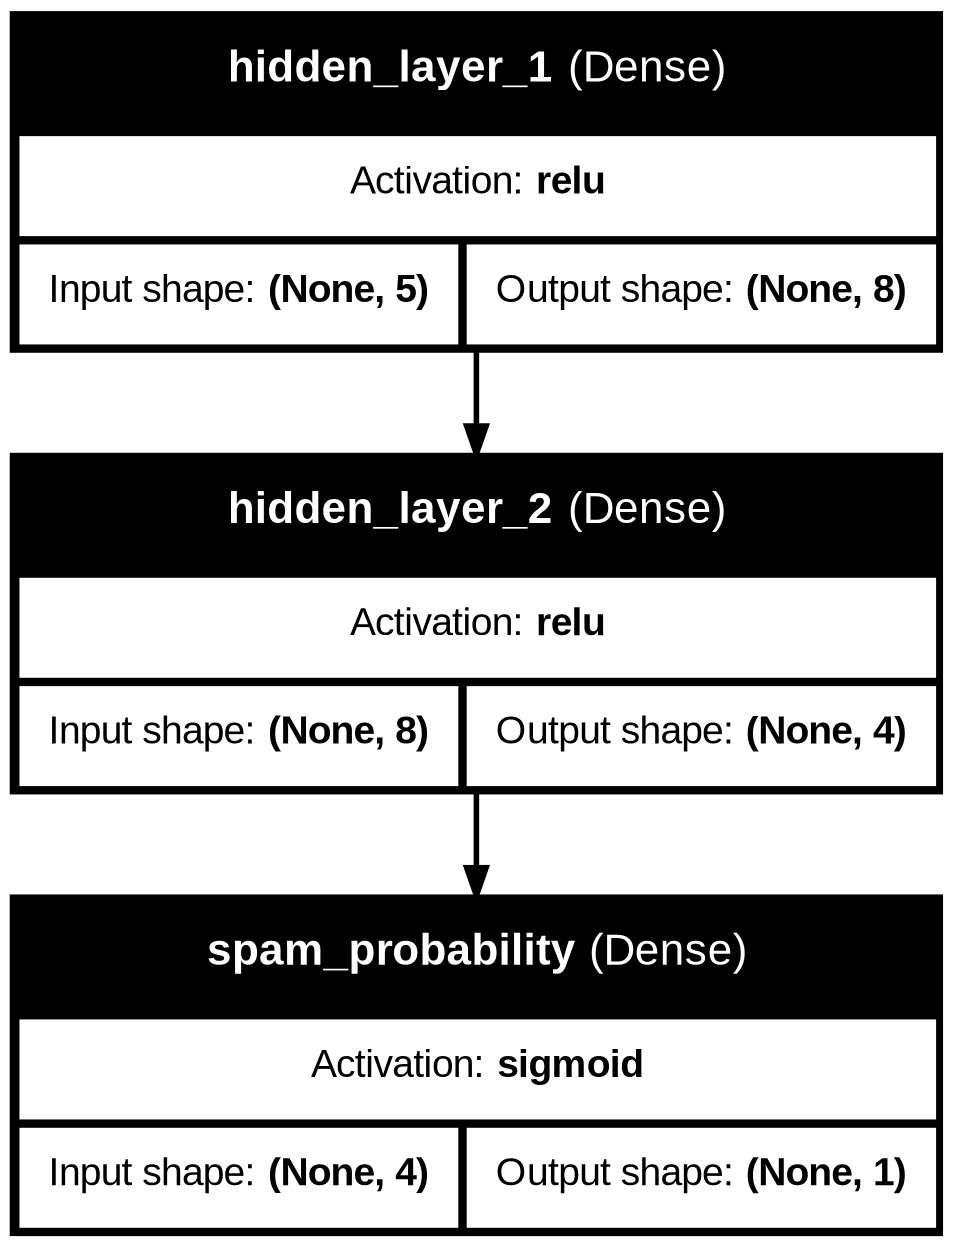

In [ ]:
tf.keras.utils.plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    show_layer_activations=True
)


## 7. Interactive architecture experiment

Change the hidden-layer sizes and observe how the number of trainable parameters changes.


In [ ]:
@widgets.interact(
    hidden_layer_1=(1, 32, 1),
    hidden_layer_2=(1, 32, 1)
)
def experiment_with_network(
    hidden_layer_1=8,
    hidden_layer_2=4
):

    experiment_model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(len(feature_names),)),

        tf.keras.layers.Dense(
            hidden_layer_1,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            hidden_layer_2,
            activation="relu"
        ),

        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )

    ])

    print()
    print(
        f"Architecture: {len(feature_names)} → {hidden_layer_1} → "
        f"{hidden_layer_2} → 1"
    )

    print()
    print(
        "Number of parameters:",
        experiment_model.count_params()
    )


interactive(children=(IntSlider(value=8, description='hidden_layer_1', max=32, min=1), IntSlider(value=4, desc…

### Challenge

Try these architectures:

- `5 → 4 → 2 → 1`
- `5 → 8 → 4 → 1`
- `5 → 32 → 16 → 1`

Which has the most parameters?

Does a larger network automatically mean a better network?


## 8. Inspect individual layers


In [ ]:
model = build_network(8, 4)

for i, layer in enumerate(model.layers):

    print(f"Layer {i + 1}")
    print("Name:", layer.name)
    print("Number of neurons:", layer.units)
    print("Activation:", layer.activation.__name__)
    print("-" * 40)


Layer 1
Name: hidden_layer_1
Number of neurons: 8
Activation: relu
----------------------------------------
Layer 2
Name: hidden_layer_2
Number of neurons: 4
Activation: relu
----------------------------------------
Layer 3
Name: spam_probability
Number of neurons: 1
Activation: sigmoid
----------------------------------------


## 9. Quick architecture quiz


In [ ]:
#@title Quick architecture quiz
import hashlib as _hashlib

_check_salt = 'spam-nn-student-check-v1'
def _digest_answer(value):
    return _hashlib.sha256((_check_salt + "|" + str(value)).encode()).hexdigest()

questions = [
    {
        "question": 'How many input values does the network receive from one email?',
        "options": ['1', '2', '5', '10'],
        "key": '04b5e3b6753b8e49bd566242709b41d2ef10d3f5d585e3aba23cbac4b661ae80'
    },
    {
        "question": 'How many output neurons are needed for this binary classifier?',
        "options": ['1', '2', '5', '10'],
        "key": '6aef9821ba19132b4191cf376edb5542d570161320f835cafa9554e819a0e366'
    },
    {
        "question": 'Which activation should we use in the final layer?',
        "options": ['ReLU', 'Sigmoid', 'None', 'Linear'],
        "key": '34b1dae1447b3ef5758e574905d53f7243c79c711fe2dec16ca541145e85cb89'
    },
]

for q in questions:
    print("\n" + q["question"])
    dropdown = widgets.Dropdown(options=q["options"])
    button = widgets.Button(description="Check")
    feedback = widgets.Output()

    def create_checker(question, widget, feedback_box):
        def check(b):
            with feedback_box:
                feedback_box.clear_output()
                if _digest_answer(widget.value) == question["key"]:
                    print("✅ Correct!")
                else:
                    print("❌ Try again.")
        return check

    button.on_click(create_checker(q, dropdown, feedback))
    display(dropdown, button, feedback)



How many input values does the network receive from one email?


Dropdown(options=('1', '2', '5', '10'), value='1')

Button(description='Check', style=ButtonStyle())

Output()


How many output neurons are needed for this binary classifier?


...

Output()


Which activation should we use in the final layer?


Dropdown(options=('ReLU', 'Sigmoid', 'None', 'Linear'), value='ReLU')

Button(description='Check', style=ButtonStyle())

Output()

## 10. Forward pass without training

We can send an email through the network even before it has learned anything.

However, because the network has not been trained, its prediction is not meaningful yet.

This step is only to demonstrate the flow:

`Email → Features → Neural Network → Output`


In [ ]:
model = build_network(8, 4)

sample_email = """
Congratulations!!!
You have WON a FREE cash prize.
Click http://claim-now.com
"""

sample_features = np.array([
    extract_features(sample_email)
])

print("Email:")
print(sample_email)

print("\nFeatures:")
print(sample_features)

prediction = model(sample_features)

print("\nNetwork output:")
print(prediction.numpy())

print("\n⚠️ The network has NOT been trained, so this output is not meaningful yet.")


Email:

Congratulations!!!
You have WON a FREE cash prize.
Click http://claim-now.com


Features:
[[ 4  3  1 79  2]]

Network output:
[[0.97636414]]

⚠️ The network has NOT been trained, so this output is not meaningful yet.


## 11. Try your own email


In [ ]:
email_box = widgets.Textarea(
    value="Congratulations! You won a FREE prize!!!",
    placeholder="Write an email here...",
    description="Email:",
    layout=widgets.Layout(
        width="80%",
        height="120px"
    )
)

analyse_button = widgets.Button(
    description="Pass through network"
)

prediction_output = widgets.Output()

def analyse_email(b):

    with prediction_output:

        prediction_output.clear_output()

        email = email_box.value

        x = np.array([
            extract_features(email)
        ])

        print("Numerical features")
        print("------------------")

        for name, value in zip(
            feature_names,
            x[0]
        ):
            print(f"{name:20s}: {value}")

        result = model(x).numpy()[0][0]

        print()
        print("Network output:")
        print(round(float(result), 4))

        print()
        print("⚠️ Remember: the network has NOT been trained.")
        print("This only demonstrates information flowing through the architecture.")

analyse_button.on_click(analyse_email)

display(
    email_box,
    analyse_button,
    prediction_output
)


Textarea(value='Congratulations! You won a FREE prize!!!', description='Email:', layout=Layout(height='120px',…

Button(description='Pass through network', style=ButtonStyle())

Output()


# Part 1 Challenge: Design Your Own Spam Network

You have explored how an email can be converted into numerical features and passed through a neural network.

Now it is your turn to **upgrade the prototype**.

### Your mission

Build a new spam-detection network that:

1. Uses the **5 existing email features**
2. Adds **1 new numerical feature of your own**
3. Uses the architecture:

`6 inputs → 10 neurons → 5 neurons → 1 output`

4. Uses suitable activation functions for:
   - the hidden layers
   - the output layer
5. Passes two emails through your network
6. Explains why the outputs are **not yet reliable spam predictions**

> **Important:** This challenge is still about the **architecture and forward pass**.  
> The network has not been trained yet.



## Challenge 1 — Add a sixth feature

Choose **one new numerical feature** that might help distinguish spam from legitimate email.

Possible ideas include:

- number of digits
- number of question marks
- number of words such as `"click"`
- number of currency symbols
- another feature you think could be useful

Complete the function below.

**Do not remove the original five features.** Your function should return **6 numerical values**.


In [ ]:
# TODO: Create your sixth feature

def extract_features_challenge(email):
    # Keep the original 5 features
    base_features = extract_features(email)

    # TODO:
    # Replace the value below with YOUR new numerical feature.
    # Example idea:
    # new_feature = sum(character.isdigit() for character in email)

    new_feature = 0

    return base_features + [new_feature]


# TODO: Give your new feature a meaningful name
challenge_feature_names = feature_names + [
    "My new feature"
]


# Test your feature extractor
test_email = "WIN $1000 NOW!!! Click http://example.com"

test_features = extract_features_challenge(test_email)

print("Features:", test_features)
print("Number of features:", len(test_features))

if len(test_features) == 6:
    print("✅ Your function returns 6 inputs.")
else:
    print("❌ Your function must return exactly 6 numerical inputs.")



## Challenge 2 — Build the new neural network

Build a Keras model with this architecture:

`6 → 10 → 5 → 1`

### Requirements

- The network must accept **6 input values**
- First hidden layer: **10 neurons**
- Second hidden layer: **5 neurons**
- Hidden layers: use the activation function you learned earlier
- Output layer: **1 neuron**
- Output activation: suitable for a binary classifier

### Before running `model.summary()`

Calculate the total number of trainable parameters **on paper**.

Remember that a Dense layer has:

\[
\text{parameters} = (\text{inputs} \times \text{neurons}) + \text{biases}
\]

Write down your predicted total before checking it with Keras.


In [ ]:
# TODO: Build your challenge model below.
#
# Requirements:
# 6 inputs → 10 neurons → 5 neurons → 1 output
#
# Suggested starting point:
#
# challenge_model = tf.keras.Sequential([
#     ...
# ])

challenge_model = None  # Replace this with your model


# When your model is ready, uncomment:
# challenge_model.summary()



## Challenge 3 — Check your architecture

Run the checker after you have created `challenge_model`.

It will check the **shape and activations**, but it will not build the model for you.


In [ ]:
# Architecture checker

candidate = globals().get("challenge_model", None)

if candidate is None:
    print("❌ Build challenge_model first.")
else:
    try:
        dense_layers = [
            layer for layer in candidate.layers
            if isinstance(layer, tf.keras.layers.Dense)
        ]

        units = [layer.units for layer in dense_layers]
        activations = [
            layer.activation.__name__
            for layer in dense_layers
        ]

        expected_units = [10, 5, 1]
        expected_activations = ["relu", "relu", "sigmoid"]

        input_size = candidate.input_shape[-1]

        print("Input size:", input_size)
        print("Dense-layer neurons:", units)
        print("Activations:", activations)
        print("Trainable parameters:", candidate.count_params())
        print()

        checks = [
            input_size == 6,
            units == expected_units,
            activations == expected_activations
        ]

        if all(checks):
            print("✅ Architecture challenge passed!")
            print("Compare the parameter count above with your handwritten calculation.")
        else:
            print("❌ Not quite yet.")

            if input_size != 6:
                print("• The network should accept 6 input values.")

            if units != expected_units:
                print("• Dense layers should contain 10, 5, and 1 neurons.")

            if activations != expected_activations:
                print("• Check the hidden- and output-layer activation functions.")

    except Exception as error:
        print("❌ The model could not be checked.")
        print("Hint: make sure challenge_model is a valid Keras Sequential model.")
        print("Details:", error)



## Challenge 4 — Test two emails

Create:

- one email that **looks spam-like**
- one email that **looks legitimate**

Pass both through your new feature extractor and your network.

Before running the cell, predict which email you think will receive the larger output.

Then compare the results.

> Remember: the network still has **random, untrained weights**, so a surprising result is completely possible.


In [ ]:
# TODO: Replace these with your own examples

spam_like_email = """
WIN a FREE $5000 prize NOW!!!
Click http://claim-prize.com
"""

legitimate_email = """
Hi team,
The project meeting has moved to 2 PM tomorrow.
Please let me know if you can attend.
"""


emails_to_test = {
    "Spam-like email": spam_like_email,
    "Legitimate email": legitimate_email
}


if globals().get("challenge_model", None) is None:
    print("❌ Build challenge_model before running this test.")
else:
    for label, email in emails_to_test.items():

        x = np.array([
            extract_features_challenge(email)
        ])

        result = challenge_model(x).numpy()[0][0]

        print("\n" + "=" * 60)
        print(label)
        print("=" * 60)
        print(email.strip())

        print("\nFeatures:")
        for name, value in zip(challenge_feature_names, x[0]):
            print(f"{name:20s}: {value}")

        print("\nNetwork output:")
        print(round(float(result), 4))

    print("\n⚠️ These outputs are NOT reliable spam probabilities.")
    print("The network has not been trained.")



## Part 1 reflection

Discuss these questions with your group:

1. **What sixth feature did you add, and why might it be useful?**
2. **How many trainable parameters does your `6 → 10 → 5 → 1` network contain?**
3. **Why does adding one new input feature change the number of parameters?**
4. **Why can the network produce an output before training?**
5. **Why should we not trust that output as a real spam prediction yet?**
6. **Could two very different emails still produce the same six feature values? What limitation does that reveal?**

### ⭐ Stretch challenge

Try to create **two emails with very different meanings but identical numerical features**.

Pass them through the network.

What do you observe, and what does this tell you about the importance of feature representation?


# Part 2: Training with Gradient Descent and Backpropagation

The network can already produce an output, but its weights are still random. In this part, you will train those weights.

### Learning goals

By the end of this part, you will be able to:

- calculate a binary cross-entropy loss
- follow gradients backward through a small network
- update weights with gradient descent
- compare learning rates
- connect a manual training loop to Keras

**Suggested time: 45 minutes**

> To keep every calculation visible, the manual example uses a `5 → 4 → 1` network. The same backpropagation process extends to deeper networks.


## 12. Add labels and a training set

Training requires examples with known answers. We will use:

- `1` for spam
- `0` for a legitimate email

This small, hand-written dataset is designed for learning. It is not large or varied enough for a real spam filter.


In [ ]:
training_examples = [
    ("Congratulations! You have WON a FREE prize!!! Click http://claim-now.com", 1),
    ("URGENT!!! Claim your CASH reward now at http://cash-now.com", 1),
    ("WIN MONEY NOW!!! A limited prize is waiting for you", 1),
    ("You were selected for a FREE gift card. Click http://gift.example", 1),
    ("Earn CASH from home!!! Visit http://earn-fast.example", 1),
    ("Your account has won a reward. Claim your prize now!", 1),
    ("FREE vacation offer expires today!!! Click http://travel-win.example", 1),
    ("WINNER! Collect MONEY at http://winner.example", 1),
    ("Urgent: your FREE reward is ready", 1),
    ("Get CASH instantly!!! Click http://loan-prize.example", 1),
    ("You have WON. Reply now to receive your prize", 1),
    ("FREE FREE FREE!!! Visit http://special-offer.example", 1),
    ("Prize alert! Click http://claim.example to collect your reward", 1),
    ("A cash reward is waiting. Verify at http://verify-prize.example", 1),
    ("Hi Sarah, can we move tomorrow's project meeting to 2 PM?", 0),
    ("Please find attached the report from yesterday's meeting.", 0),
    ("Would you like to have lunch with the design team tomorrow?", 0),
    ("The invoice for August is ready for your review.", 0),
    ("Reminder: your dentist appointment is Friday at 10 AM.", 0),
    ("Here is the latest project update and list of open questions.", 0),
    ("Thank you for your presentation. The team found it useful!", 0),
    ("Your package will arrive tomorrow between 9 AM and noon.", 0),
    ("Please review the dashboard at http://intranet.example", 0),
    ("Great work on the release! Let's discuss the results Monday.", 0),
    ("URGENT: the production server needs a restart by the IT team.", 0),
    ("Please add the cash expense to this month's report.", 0),
    ("Congratulations on your promotion! You earned it.", 0),
    ("The workshop schedule is at http://company.example/training", 0),
]

training_emails = [email for email, label in training_examples]
X_all = np.array([extract_features(email) for email in training_emails], dtype=np.float64)
y_all = np.array([label for email, label in training_examples], dtype=np.float64).reshape(-1, 1)

training_df = pd.DataFrame(X_all.astype(int), columns=feature_names)
training_df.insert(0, "Label", y_all.astype(int).ravel())
training_df.insert(0, "Email", training_emails)

display(training_df.head(10))
print("Examples:", len(training_df))
print("Spam examples:", int(y_all.sum()))
print("Legitimate examples:", int(len(y_all) - y_all.sum()))


## 13. Split and scale the data

We keep six emails aside for testing. The network will never use those six examples to update its weights.

The five features also have very different scales. Email length can be much larger than the number of links, so we standardize every feature using statistics from the training set.


In [ ]:
split_rng = np.random.default_rng(21)

spam_indices = np.where(y_all.ravel() == 1)[0]
legitimate_indices = np.where(y_all.ravel() == 0)[0]
split_rng.shuffle(spam_indices)
split_rng.shuffle(legitimate_indices)

test_indices = np.concatenate([spam_indices[:3], legitimate_indices[:3]])
train_indices = np.concatenate([spam_indices[3:], legitimate_indices[3:]])
split_rng.shuffle(train_indices)
split_rng.shuffle(test_indices)

X_train_raw = X_all[train_indices]
X_test_raw = X_all[test_indices]
y_train = y_all[train_indices]
y_test = y_all[test_indices]

feature_mean = X_train_raw.mean(axis=0, keepdims=True)
feature_std = X_train_raw.std(axis=0, keepdims=True)
feature_std = np.where(feature_std == 0, 1.0, feature_std)

def scale_features(raw_features):
    return (raw_features - feature_mean) / feature_std

X_train = scale_features(X_train_raw)
X_test = scale_features(X_test_raw)

print("Training shape:", X_train.shape, y_train.shape)
print("Test shape:    ", X_test.shape, y_test.shape)
print("Training labels:", np.bincount(y_train.astype(int).ravel()))
print("Test labels:    ", np.bincount(y_test.astype(int).ravel()))


## 14. The forward pass and loss

Our manual network has one hidden layer:

`5 inputs → 4 ReLU neurons → 1 sigmoid output`

The forward pass is:

\[
Z_1 = XW_1 + b_1
\]

\[
A_1 = \operatorname{ReLU}(Z_1)
\]

\[
Z_2 = A_1W_2 + b_2, \qquad \hat{y} = \sigma(Z_2)
\]

Binary cross-entropy measures how far the predicted probabilities are from the labels:

\[
L = -\frac{1}{m}\sum_{i=1}^{m} \left[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]
\]


In [ ]:
def relu(z):
    return np.maximum(0.0, z)

def sigmoid(z):
    z = np.clip(z, -30, 30)
    return 1.0 / (1.0 + np.exp(-z))

def binary_cross_entropy(y_true, y_probability):
    probability = np.clip(y_probability, 1e-9, 1 - 1e-9)
    return float(-np.mean(
        y_true * np.log(probability)
        + (1 - y_true) * np.log(1 - probability)
    ))

def initialize_parameters(input_size=5, hidden_size=4, seed=7):
    rng = np.random.default_rng(seed)
    return {
        "W1": rng.normal(0, np.sqrt(2 / input_size), size=(input_size, hidden_size)),
        "b1": np.zeros((1, hidden_size)),
        "W2": rng.normal(0, np.sqrt(2 / hidden_size), size=(hidden_size, 1)),
        "b2": np.zeros((1, 1)),
    }

def forward_pass(X, parameters):
    Z1 = X @ parameters["W1"] + parameters["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ parameters["W2"] + parameters["b2"]
    A2 = sigmoid(Z2)

    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache


### Inspect the untrained network

Before running the next cell, predict what probabilities you expect from random weights. Should the loss already be close to zero?


In [ ]:
initial_parameters = initialize_parameters()
initial_probabilities, initial_cache = forward_pass(X_train, initial_parameters)
initial_loss = binary_cross_entropy(y_train, initial_probabilities)

preview = pd.DataFrame({
    "Actual label": y_train[:8].astype(int).ravel(),
    "Initial probability": np.round(initial_probabilities[:8].ravel(), 4),
})

display(preview)
print("Initial loss:", round(initial_loss, 4))
print("The probabilities are not useful yet because the weights are random.")


## 15. Backpropagation

Backpropagation applies the chain rule from the loss back to every weight and bias. It answers: **How would a small change in this parameter change the loss?**

For sigmoid output with binary cross-entropy, the first derivative simplifies to:

\[
dZ_2 = \frac{\hat{y} - y}{m}
\]

The gradients then move backward through the output layer:

\[
dW_2 = A_1^T dZ_2, \qquad db_2 = \sum dZ_2
\]

and through the ReLU hidden layer:

\[
dA_1 = dZ_2 W_2^T, \qquad dZ_1 = dA_1 \odot \mathbb{1}[Z_1 > 0]
\]

\[
dW_1 = X^T dZ_1, \qquad db_1 = \sum dZ_1
\]

Notice that backpropagation **calculates gradients**. It does not update the parameters.


In [ ]:
def backward_pass(X, y_true, parameters, cache):
    m = X.shape[0]
    Z1 = cache["Z1"]
    A1 = cache["A1"]
    A2 = cache["A2"]

    # Output layer: sigmoid combined with binary cross-entropy
    dZ2 = (A2 - y_true) / m
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Hidden layer: follow the chain rule through W2 and ReLU
    dA1 = dZ2 @ parameters["W2"].T
    dZ1 = dA1 * (Z1 > 0)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

initial_gradients = backward_pass(
    X_train, y_train, initial_parameters, initial_cache
)

for name, gradient in initial_gradients.items():
    print(f"{name:4s} shape={str(gradient.shape):8s} norm={np.linalg.norm(gradient):.6f}")


### Gradient check

A numerical gradient gives us an independent way to check the backpropagation code. We slightly increase and decrease one weight, observe the change in loss, and compare that slope with `dW1`.


In [ ]:
epsilon = 1e-5
parameter_name = "W1"
parameter_index = (0, 0)

parameters_plus = {name: value.copy() for name, value in initial_parameters.items()}
parameters_minus = {name: value.copy() for name, value in initial_parameters.items()}
parameters_plus[parameter_name][parameter_index] += epsilon
parameters_minus[parameter_name][parameter_index] -= epsilon

probability_plus, _ = forward_pass(X_train, parameters_plus)
probability_minus, _ = forward_pass(X_train, parameters_minus)
loss_plus = binary_cross_entropy(y_train, probability_plus)
loss_minus = binary_cross_entropy(y_train, probability_minus)

numerical_gradient = (loss_plus - loss_minus) / (2 * epsilon)
backprop_gradient = initial_gradients["dW1"][parameter_index]
relative_error = abs(numerical_gradient - backprop_gradient) / max(
    1e-12, abs(numerical_gradient) + abs(backprop_gradient)
)

print("Backpropagation gradient:", backprop_gradient)
print("Numerical gradient:      ", numerical_gradient)
print("Relative error:          ", relative_error)

if relative_error < 1e-6:
    print("✅ The gradients agree.")
else:
    print("⚠️ Recheck the backward-pass equations.")


## 16. Gradient descent

Gradient descent uses the gradients to change each parameter:

\[
\theta_{new} = \theta_{old} - \eta \nabla_{\theta} L
\]

Here, `η` is the learning rate. Before running the cell, predict whether one update should increase or decrease the loss.


In [ ]:
def update_parameters(parameters, gradients, learning_rate):
    updated = {name: value.copy() for name, value in parameters.items()}
    updated["W1"] -= learning_rate * gradients["dW1"]
    updated["b1"] -= learning_rate * gradients["db1"]
    updated["W2"] -= learning_rate * gradients["dW2"]
    updated["b2"] -= learning_rate * gradients["db2"]
    return updated

one_step_parameters = update_parameters(
    initial_parameters, initial_gradients, learning_rate=0.1
)
one_step_probabilities, _ = forward_pass(X_train, one_step_parameters)
one_step_loss = binary_cross_entropy(y_train, one_step_probabilities)

print("Loss before update:", round(initial_loss, 6))
print("Loss after update: ", round(one_step_loss, 6))
print("Change in loss:     ", round(one_step_loss - initial_loss, 6))


## 17. The complete training loop

One training step contains four operations:

1. Run the forward pass.
2. Measure the loss.
3. Run backpropagation.
4. Update the parameters with gradient descent.

Training repeats this sequence many times.


In [ ]:
import matplotlib.pyplot as plt

def train_network(X, y_true, hidden_size=4, learning_rate=0.1, epochs=800, seed=7):
    parameters = initialize_parameters(
        input_size=X.shape[1], hidden_size=hidden_size, seed=seed
    )
    loss_history = []

    for epoch in range(epochs):
        probabilities, cache = forward_pass(X, parameters)
        loss = binary_cross_entropy(y_true, probabilities)
        gradients = backward_pass(X, y_true, parameters, cache)
        parameters = update_parameters(parameters, gradients, learning_rate)
        loss_history.append(loss)

    return parameters, loss_history

def network_accuracy(X, y_true, parameters):
    probabilities, _ = forward_pass(X, parameters)
    predictions = (probabilities >= 0.5).astype(int)
    return float(np.mean(predictions == y_true)), probabilities

manual_parameters, manual_loss_history = train_network(
    X_train, y_train, learning_rate=0.1, epochs=800
)

train_accuracy, train_probabilities = network_accuracy(
    X_train, y_train, manual_parameters
)
test_accuracy, test_probabilities = network_accuracy(
    X_test, y_test, manual_parameters
)

plt.figure(figsize=(8, 4))
plt.plot(manual_loss_history)
plt.xlabel("Training epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Manual network training loss")
plt.grid(alpha=0.25)
plt.show()

print(f"Training accuracy: {train_accuracy:.1%}")
print(f"Test accuracy:     {test_accuracy:.1%}")
print()
print("Interpret the test result cautiously: the test set contains only six emails.")


## 18. Learning-rate experiment

The learning rate controls the size of every update. Compare a small, suitable, and very large value.

Before running the cell, sketch the loss curve you expect for each learning rate.


In [ ]:
learning_rates = [0.001, 0.1, 10.0]
learning_rate_results = {}

plt.figure(figsize=(9, 5))

for rate in learning_rates:
    parameters_for_rate, history_for_rate = train_network(
        X_train, y_train, learning_rate=rate, epochs=300, seed=7
    )
    learning_rate_results[rate] = (parameters_for_rate, history_for_rate)
    plt.plot(history_for_rate, label=f"learning rate = {rate}")
    print(f"rate={rate:<6} final loss={history_for_rate[-1]:.4f}")

plt.xlabel("Training epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("How the learning rate changes training")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print()
print("Try replacing one value in learning_rates and run the experiment again.")


## 19. The same process in Keras

Keras performs the same operations. During `fit`, TensorFlow records the forward pass, applies backpropagation automatically, and lets the SGD optimizer update the parameters.

We use the original `5 → 8 → 4 → 1` architecture and full-batch gradient descent with Keras's SGD optimizer so the connection with the manual loop remains clear.


In [ ]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(7)

trained_model = build_network(8, 4)
trained_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

keras_history = trained_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=150,
    batch_size=len(X_train),
    shuffle=False,
    verbose=0,
)

test_loss, test_accuracy = trained_model.evaluate(X_test, y_test, verbose=0)

plt.figure(figsize=(8, 4))
plt.plot(keras_history.history["loss"], label="Training loss")
plt.plot(keras_history.history["val_loss"], label="Test loss")
plt.xlabel("Training epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Keras training history")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print(f"Keras test loss:     {test_loss:.4f}")
print(f"Keras test accuracy: {test_accuracy:.1%}")


## 20. Test trained predictions

The function below applies the same feature scaling used during training. Add one spam-like email and one legitimate email of your own. Predict the outputs before running the cell.


In [ ]:
def compare_trained_predictions(email):
    raw = np.array([extract_features(email)], dtype=np.float64)
    scaled = scale_features(raw)

    manual_probability, _ = forward_pass(scaled, manual_parameters)
    keras_probability = trained_model.predict(scaled, verbose=0)[0, 0]

    return {
        "Email": email.strip().replace("\n", " "),
        "Manual network": float(manual_probability[0, 0]),
        "Keras network": float(keras_probability),
    }

new_emails = [
    "URGENT!!! You have WON a FREE cash prize. Click http://claim.example",
    "Hi team, please review the project notes before tomorrow's meeting.",
    # TODO: Add your own examples here.
]

comparison = pd.DataFrame([
    compare_trained_predictions(email) for email in new_emails
])

display(comparison.style.format({
    "Manual network": "{:.3f}",
    "Keras network": "{:.3f}",
}))

print("Values near 1 indicate spam; values near 0 indicate legitimate email.")
print("These results still come from a tiny teaching dataset, not a production model.")


## Training lab reflection

Discuss these questions with your group:

1. What does backpropagation calculate?
2. How does gradient descent use those calculations?
3. Why did we scale the five input features?
4. What happened when the learning rate was too small or too large?
5. Why can a model have high accuracy on this test set and still perform poorly on real email?
6. Which incorrect prediction would help you design a better feature?

### Key distinction

> **Backpropagation calculates the gradients. Gradient descent uses the gradients to update the parameters.**

### Optional extension

Change one element at a time and rerun the training:

- hidden-layer size
- number of training epochs
- learning rate
- one of the hand-crafted email features

Record how the loss curve and test predictions change.
